In [1]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/clean_loan_data.csv"
)

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,IncomePerPerson,LoanIncomeRatio
0,0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1,5849.0,5849.0,0.021884
1,1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0,6091.0,6091.0,0.021015
2,2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1,3000.0,3000.0,0.022000
3,3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1,4941.0,4941.0,0.024287
4,4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1,6000.0,6000.0,0.023500


In [2]:
X = df.drop(
    ["Loan_ID","Loan_Status"],
    axis=1
)

y = df["Loan_Status"]

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [4]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [5]:
pred_rf = rf.predict(X_test)

In [6]:
from sklearn.metrics import accuracy_score

accuracy_score(
    y_test,
    pred_rf
)

0.8699186991869918

In [7]:
# Classification Report
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.92      0.63      0.75        38
           1       0.86      0.98      0.91        85

    accuracy                           0.87       123
   macro avg       0.89      0.80      0.83       123
weighted avg       0.88      0.87      0.86       123



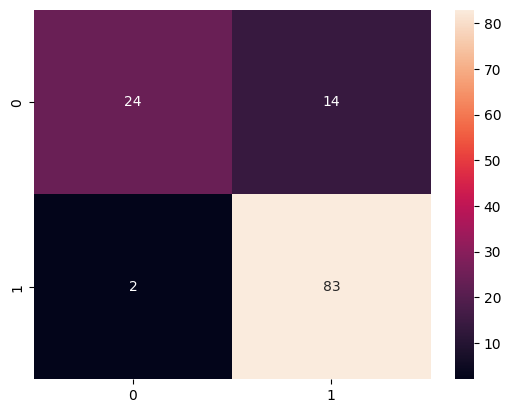

In [21]:
# Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    pred_rf
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.show()

In [11]:
pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.


In [12]:
# XGBoost Model (Recommended)
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train,y_train)

pred_xgb = xgb.predict(X_test)

In [13]:
accuracy_score(
    y_test,
    pred_xgb
)

0.8373983739837398

In [14]:
# ROC AUC
from sklearn.metrics import roc_auc_score

roc_auc_score(
    y_test,
    pred_xgb
)

0.8095975232198143

In [15]:
# Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
9,Credit_History,0.397772
4,Self_Employed,0.054566
12,IncomePerPerson,0.052670
1,Married,0.052413
10,Property_Area,0.050035
3,Education,0.049502
8,Loan_Amount_Term,0.049391
6,CoapplicantIncome,0.047563
5,ApplicantIncome,0.046817
11,TotalIncome,0.045667


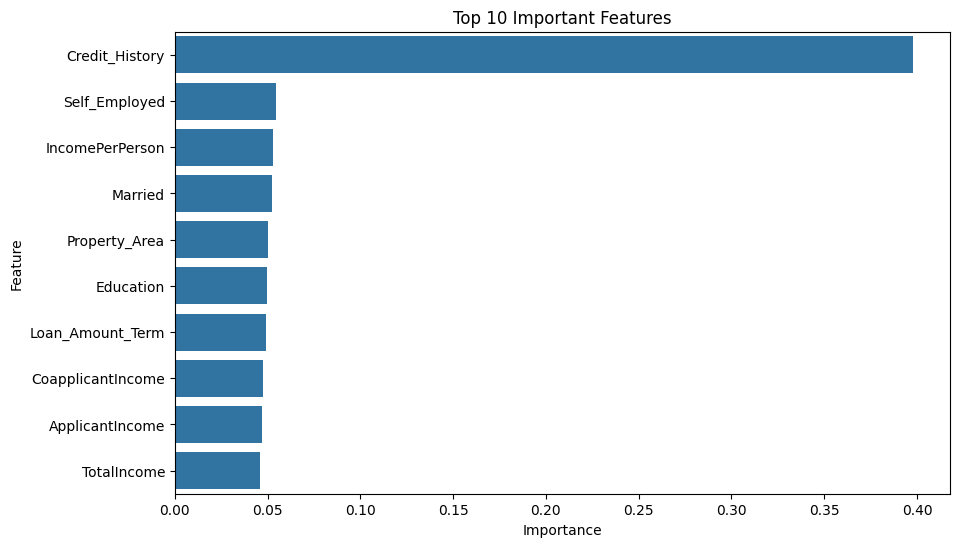

In [18]:
# Visualization
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Important Features"
)

plt.show()

In [20]:
# Save Model
import joblib

joblib.dump(
    xgb,
    "../artifacts/model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully
